<div style="text-align: center;">
<font color="black" size=+3.5><b> Heart Diseases: What are the indicators? </b></font>
</div>

<div>    
<img src="https://images2.minutemediacdn.com/image/upload/c_fill,w_1080,ar_16:9,f_auto,q_auto,g_auto/shape%2Fcover%2Fsport%2F535618-istock-819924240-2470f65174198a2b48b33619995f99ad.jpg" width="550/">    
</div>


[Image source >>](https://www.mentalfloss.com/article/535618/super-ekg-could-diagnose-heart-disease-90-seconds)


# 0. **Introduction** <a class="anchor" id="0"></a>
"Heart disease is broad term used for diseases and conditions affecting the heart and circulatory system. They are also referred as cardiovascular diseases. It is a major cause of disability all around the world. Since heart is amongst the most vital organs of the body, its diseases affect other organs and part of the body as well. There are several different types and forms of heart diseases. The most common ones cause narrowing or blockage of the coronary arteries, malfunctioning in the valves of the heart, enlargement in the size of heart and several others leading to **heart failure** and **heart attack**." [[Source](https://www.indushealthplus.com/heart-diseases.html)]

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color: #4e4e4e; padding: 1em; margin:24px;">

<font color="white" size=+1.0><b>Key facts according to WHO (World Health Organaizations)</b></font>  
        
<ul>
<li> Cardiovascular diseases (CVDs) are the leading cause of death globally.
<li> An estimated 17.9 million people died from CVDs in 2019, representing 32% of all global deaths. Of these deaths, 85% were due to heart attack and stroke.
<li> Over three quarters of CVD deaths take place in low- and middle-income countries.
<li> Out of the 17 million premature deaths (under the age of 70) due to noncommunicable diseases in 2019, 38% were caused by CVDs.
<li> Most cardiovascular diseases can be prevented by addressing behavioural risk factors such as tobacco use, unhealthy diet and obesity, physical inactivity and harmful use of alcohol.
<li> It is important to detect cardiovascular disease as early as possible so that management with counselling and medicines can begin.                                                                                                                                 
    
</ul>        
</blockquote>

#### **Objectives**
This notebook has two main objectives:
* Explore the heart disease dataset using exploratory data analysis (EDA)
* Exercise with classification algorithms for prediction (modelling) 
---

<a id="top"></a>

## **Table of Contents**

* [0. Introduction](#0)
* [1. Exploratory Data Analysis](#1)
    * [1.1 Data Dictionary](#1.1)
    * [1.2 Data Pre-processing](#1.2)
    * [1.3 Exploring Features](#1.3)
    * [1.4 Correlations Heatmap](#1.4)
    * [1.5 EDA Summary](#1.5)
* [2. Predictions](#2)
    * [2.1 Scikit Learn Classifiers](#2.1)
    * [2.2 Catboost, Lgbm and Xgboost](#2.2)
    * [2.3 Model Explainablity](#2.3)
* [3. Concluding Remarks](#3)
* [4. Reference](#4)


---
# 1. **Exploratory Data Analysis** <a class="anchor" id="1"></a>
---

In [47]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from IPython.core.display import HTML
import matplotlib.pyplot as plt
from scipy.stats import uniform

import warnings
warnings.filterwarnings('ignore')

import os


In [48]:
data = pd.read_csv('../../data/heart_disease_prediction/heart.csv')
print('Shape of the data is ', data.shape)

Shape of the data is  (303, 14)


In [49]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [50]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

**Note**: From the data types we see that all features are `int64/float64`. But that is because some of the categorical features including the target (has disease/no disease) are already label encoded for us. We will, in the section below, see a detailed decreption of the features.

---
## 1.1 **Data Dictionary** <a class="anchor" id="1.1"></a>

1. age: age in years
2. sex: sex 
    * 1 = male
    * 0 = female
3. cp: chest pain type
    * Value 0: typical angina
    * Value 1: atypical angina
    * Value 2: non-anginal pain
    * Value 3: asymptomatic
4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholestoral in mg/dl
6. fbs: (fasting blood sugar > 120 mg/dl) 
    * 1 = true; 
    * 0 = false
7. restecg: resting electrocardiographic results
    * Value 0: normal
    * Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    * Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. thalach: maximum heart rate achieved
9. exang: exercise induced angina 
    * 1 = yes
    * 0 = no
10. oldpeak = ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
    * Value 0: upsloping
    * Value 1: flat
    * Value 2: downsloping
12. ca: number of major vessels (0-3) colored by flourosopy
13. thal: 
    * 0 = `error (in the original dataset 0 maps to NaN's)`
    * 1 = fixed defect
    * 2 = normal 
    * 3 = reversable defect 
14. target (the lable): 
    * 0 = no disease, 
    * 1 = disease
---    
**Note on the target label**:

`Diagnosis of heart disease (angiographic disease status)
Value 0: < 50% diameter narrowing
Value 1: > 50% diameter narrowing`
    
**Notes from the discussion forum of the dataset**:

* data #93, 159, 164, 165 and 252 have `ca=4` which is incorrect. In the original Cleveland dataset they are NaNs.
* data #49 and 282 have `thal = 0`, also incorrect. They are also NaNs in the original dataset.

**Action**:  Drop the faulty data! (7 data entry will be dropped)

---

<a href="#top">Back to top</a>

## 1.2 **Data pre-processing** <a class="anchor" id="1.2"></a>
### 1.2.1 Drop faulty data
Based on our investigation we did above, we will drop 7 rows.

In [51]:
data = data[data['ca'] < 4] #drop the wrong ca values
data = data[data['thal'] > 0] # drop the wong thal value
print(f'The length of the data now is {len(data)} instead of 303!')

The length of the data now is 296 instead of 303!


### 1.2.2 Rename columns for the sake of clarity
* The feature names in the dataset are abbreviated and hard to understand their meaning. A full medical/technical name is hard enough to understand for most of us let alone their short form. So to make them a little bit easier to read we will, here under, change the column names of the data frame using information from the UCL data repository.
* We'll also replace the coded categories (0, 1, 2,..) to their medical meaning ('atypical angina', 'typical angina', etc. for example)
* **Note**: I borrowed [Rob Harrand's](https://www.kaggle.com/tentotheminus9/what-causes-heart-disease-explaining-the-model) idea of re-naming the columns.

In [52]:
data = data.rename(
    columns = {'cp':'chest_pain_type', 
               'trestbps':'resting_blood_pressure', 
               'chol': 'cholesterol',
               'fbs': 'fasting_blood_sugar',
               'restecg' : 'resting_electrocardiogram', 
               'thalach': 'max_heart_rate_achieved', 
               'exang': 'exercise_induced_angina',
               'oldpeak': 'st_depression', 
               'slope': 'st_slope', 
               'ca':'num_major_vessels', 
               'thal': 'thalassemia'}, 
    errors="raise")

In [53]:
data['sex'][data['sex'] == 0] = 'female'
data['sex'][data['sex'] == 1] = 'male'

data['chest_pain_type'][data['chest_pain_type'] == 0] = 'typical angina'
data['chest_pain_type'][data['chest_pain_type'] == 1] = 'atypical angina'
data['chest_pain_type'][data['chest_pain_type'] == 2] = 'non-anginal pain'
data['chest_pain_type'][data['chest_pain_type'] == 3] = 'asymptomatic'

data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 0] = 'lower than 120mg/ml'
data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 1] = 'greater than 120mg/ml'

data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 0] = 'normal'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 1] = 'ST-T wave abnormality'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 2] = 'left ventricular hypertrophy'

data['exercise_induced_angina'][data['exercise_induced_angina'] == 0] = 'no'
data['exercise_induced_angina'][data['exercise_induced_angina'] == 1] = 'yes'

data['st_slope'][data['st_slope'] == 0] = 'upsloping'
data['st_slope'][data['st_slope'] == 1] = 'flat'
data['st_slope'][data['st_slope'] == 2] = 'downsloping'

data['thalassemia'][data['thalassemia'] == 1] = 'fixed defect'
data['thalassemia'][data['thalassemia'] == 2] = 'normal'
data['thalassemia'][data['thalassemia'] == 3] = 'reversable defect'

In [54]:
data.dtypes

age                            int64
sex                           object
chest_pain_type               object
resting_blood_pressure         int64
cholesterol                    int64
fasting_blood_sugar           object
resting_electrocardiogram     object
max_heart_rate_achieved        int64
exercise_induced_angina       object
st_depression                float64
st_slope                      object
num_major_vessels              int64
thalassemia                   object
target                         int64
dtype: object

In [55]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,male,asymptomatic,145,233,greater than 120mg/ml,normal,150,no,2.3,upsloping,0,fixed defect,1
1,37,male,non-anginal pain,130,250,lower than 120mg/ml,ST-T wave abnormality,187,no,3.5,upsloping,0,normal,1
2,41,female,atypical angina,130,204,lower than 120mg/ml,normal,172,no,1.4,downsloping,0,normal,1
3,56,male,atypical angina,120,236,lower than 120mg/ml,ST-T wave abnormality,178,no,0.8,downsloping,0,normal,1
4,57,female,typical angina,120,354,lower than 120mg/ml,ST-T wave abnormality,163,yes,0.6,downsloping,0,normal,1


### 1.2.3 Grouping Features (by data type)
* As we have seen above there are three datatypes i.e **object**, **int** and **floats**. Let's group them according to type.


In [56]:
# numerical fearures 6
num_feats = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels']
# categorical (binary)
bin_feats = ['sex', 'fasting_blood_sugar', 'exercise_induced_angina', 'target']
# caterorical (multi-)
nom_feats= ['chest_pain_type', 'resting_electrocardiogram', 'st_slope', 'thalassemia']
cat_feats = nom_feats + bin_feats

## 1.3 **Exploring Features/Target** <a class="anchor" id="1.3"></a>

In this section we'll investigate all the features (including the target) in detail. We will look at the statistical summary when possible and the distributions of some of them as well, starting from the target.

### 1.3.1 Target distribution
 
We observe that the target is fairly balanced with ~46% with no heart disease and ~54% with heart disease. So no need to worry about target imbalance.


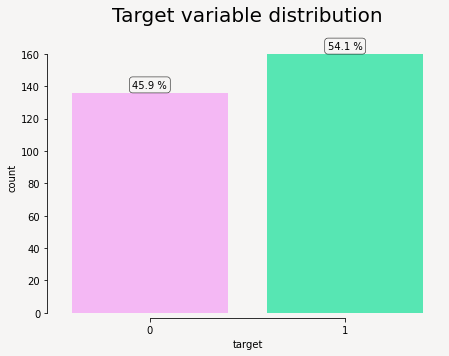

In [57]:
mypal= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA']

plt.figure(figsize=(7, 5),facecolor='#F6F5F4')
total = float(len(data))
ax = sns.countplot(x=data['target'], palette=mypal[1::4])
ax.set_facecolor('#F6F5F4')

for p in ax.patches:
    
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.1f} %'.format((height/total)*100), ha="center",
           bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))

ax.set_title('Target variable distribution', fontsize=20, y=1.05)
sns.despine(right=True)
sns.despine(offset=5, trim=True)

### 1.3.2 Numerical Features

#### Statistical summary

For the numerical features we can apply the handy pandas `data.describe()` method and get the global statistical summary. Key figures are highlighted below.

In [58]:
data[num_feats].describe().T

,count,mean,std,min,25%,50%,75%,max
age,296.0,54.523649,9.059471,29.0,48.0,56.0,61.00,77.0
cholesterol,296.0,247.155405,51.977011,126.0,211.0,242.5,275.25,564.0
resting_blood_pressure,296.0,131.604730,17.726620,94.0,120.0,130.0,140.00,200.0
max_heart_rate_achieved,296.0,149.560811,22.970792,71.0,133.0,152.5,166.00,202.0
st_depression,296.0,1.059122,1.166474,0.0,0.0,0.8,1.65,6.2
num_major_vessels,296.0,0.679054,0.939726,0.0,0.0,0.0,1.00,3.0


### **Statistical summary of the numerical features**

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color: #4e4e4e; padding: 1em; margin:24px;">
   
<ul>
<li> <font color="white" size=+1.0><b>Age</b></font> :
    <ul>
    <li> The average age in the dataset is 54.5 years
    <li> The oldest is 77 years, whereas the youngest is 29 years old
    </ul>
<li> <font color="white" size=+1.0><b>Cholesterol:</b></font>
    <ul>
    <li> The average registered cholestrol level is 247.15
    <li> Maximum level is 564 and the minimum level is 126. 
    <li> <strong>Note</strong>: According to [6], a healthy cholesterol level is $<200 mg/dl$ and usually high level of cholesterol is associated with heart disease.
    </ul>
<li> <font color="white" size=+1.0><b>Resting blood pressure:</b></font>
    <ul>
    <li> 131 mean, 200 max and 94 min
    </ul>
<li> <font color="white" size=+1.0><b>Max heart rate achieved:</b></font>
    <ul>
    <li> The abverage max heart rate registered is 149.5 bpm. The Maximum and the minumum are 202 and 71bpm respectively. 
    </ul>
<li> <font color="white" size=+1.0><b>St_depression:</b></font>
    <ul>
    <li> The average value of st_dpression is 1.06. Max is 6.2 and the minimum is 0.
    </ul>
<li> <font color="white" size=+1.0><b>Number of major blood vessels:</b></font>
    <ul>
    <li> A maximum of 3 and a minimum of 0 major blood vessels are observed. The mean value is 0.68.
    </ul>
</ul>                                                                                                                                             
</blockquote>

<a href="#top">Back to top</a>                                                                                                                                                   

#### Distribution: Density plots

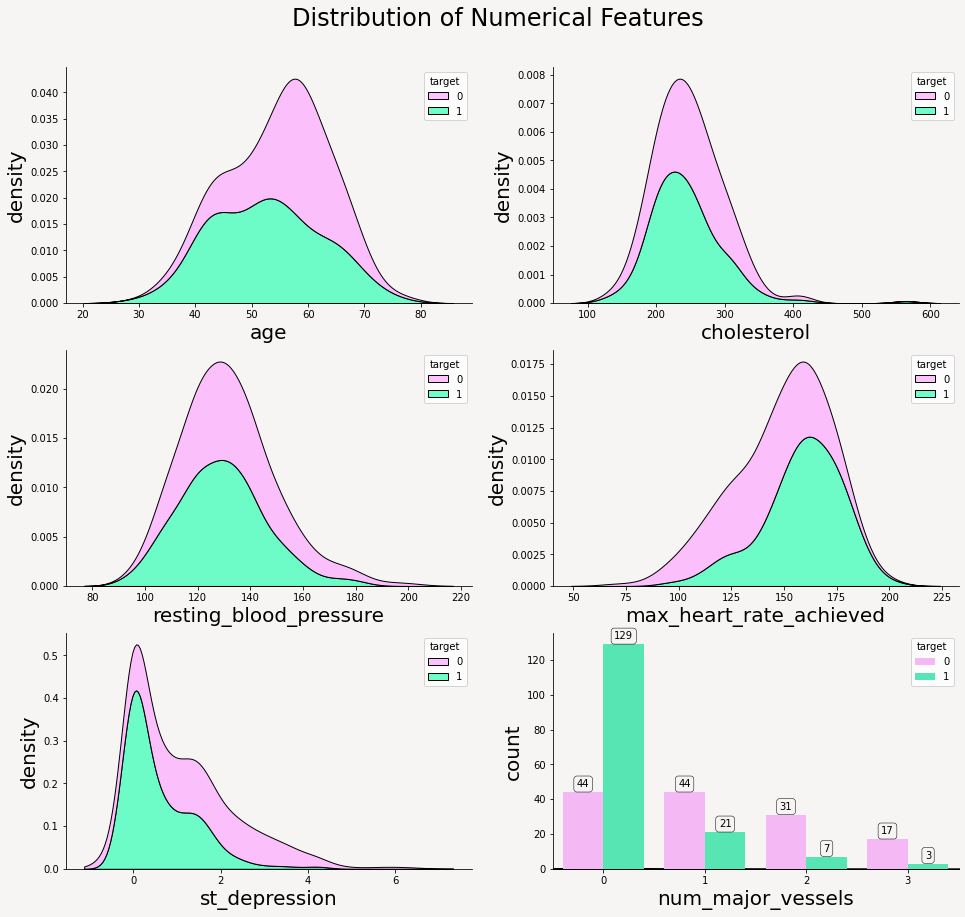

In [59]:
L = len(num_feats)
ncol= 2
nrow= int(np.ceil(L/ncol))
#remove_last= (nrow * ncol) - L

fig, ax = plt.subplots(nrow, ncol, figsize=(16, 14),facecolor='#F6F5F4')   
fig.subplots_adjust(top=0.92)

i = 1
for col in num_feats:
    plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')
    
    ax = sns.kdeplot(data=data, x=col, hue="target", multiple="stack", palette=mypal[1::4]) 
    ax.set_xlabel(col, fontsize=20)
    ax.set_ylabel("density", fontsize=20)
    sns.despine(right=True)
    sns.despine(offset=0, trim=False)
    
    if col == 'num_major_vessels':
        sns.countplot(data=data, x=col, hue="target", palette=mypal[1::4])
        for p in ax.patches:
                height = p.get_height()
                ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.0f}'.format((height)),ha="center",
                      bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))
    
    i = i +1
plt.suptitle('Distribution of Numerical Features' ,fontsize = 24);

#### Pair-plots

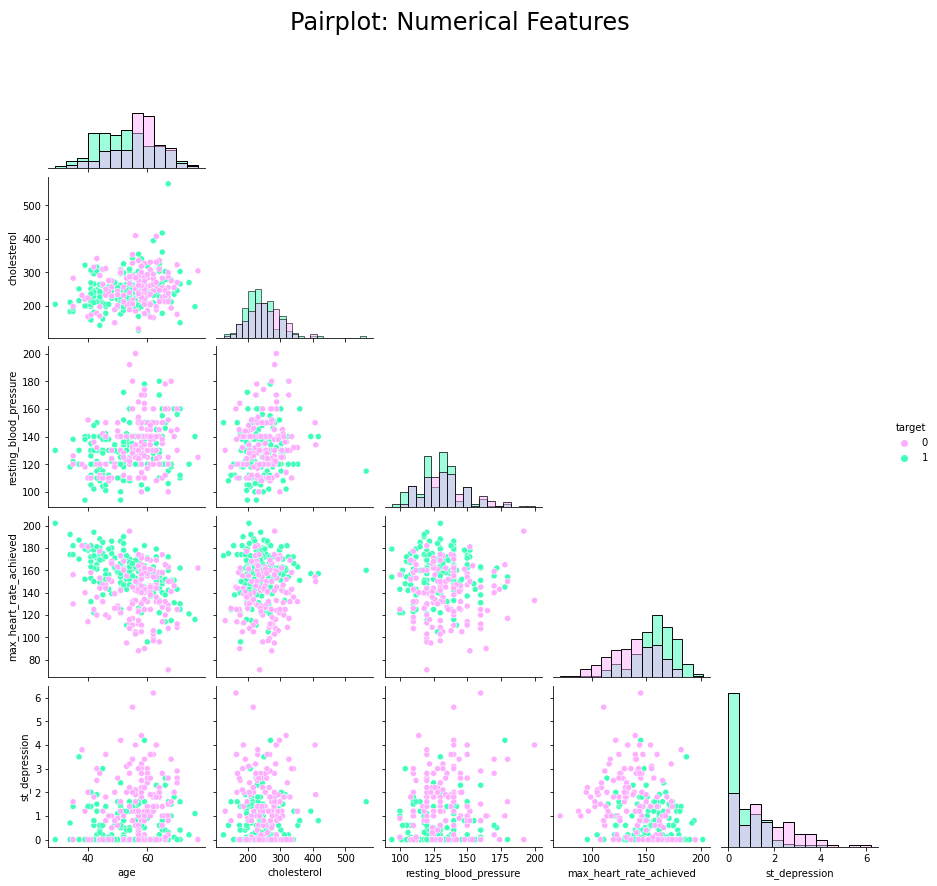

In [60]:
_ = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'target']
data_ = data[_]
g = sns.pairplot(data_, hue="target", corner=True, diag_kind='hist', palette=mypal[1::4]);
plt.suptitle('Pairplot: Numerical Features ' ,fontsize = 24);

#### Selected Features

Below are reg-plots of some selected features showing the linear relation with Age, similar to the first column in the pair-plot above. We observe that:
- Except `maximum_heart_rate_achieved`, the others are positively and linearly related with `age` (albeit a weaker relation with `st_depression`). 
- Younger patients with higher `maximum_heart_rate_achieved` are more likely to have a heart condition. 
- Lower `st_depression` regardless of age is also likely an indication of a heart disease.


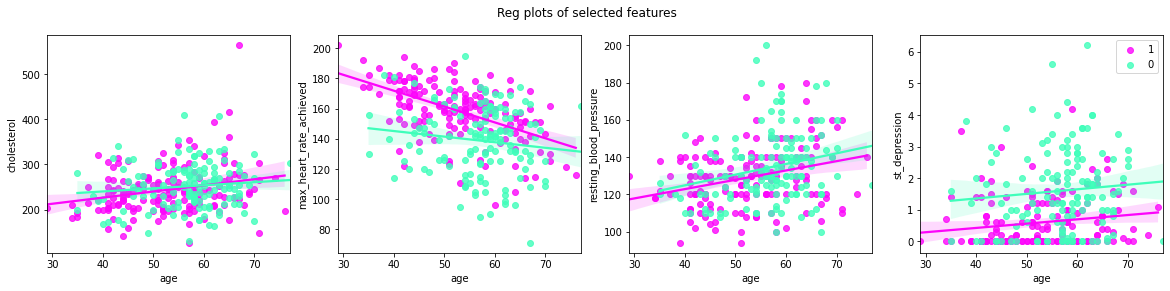

In [61]:
fig, ax = plt.subplots(1,4, figsize=(20, 4))
sns.regplot(data=data[data['target'] ==1], x='age', y='cholesterol', ax = ax[0], color=mypal[0], label='1')
sns.regplot(data=data[data['target'] ==0], x='age', y='cholesterol', ax = ax[0], color=mypal[5], label='0')
sns.regplot(data=data[data['target'] ==1], x='age', y='max_heart_rate_achieved', ax = ax[1], color=mypal[0], label='1')
sns.regplot(data=data[data['target'] ==0], x='age', y='max_heart_rate_achieved', ax = ax[1], color=mypal[5], label='0')
sns.regplot(data=data[data['target'] ==1], x='age', y='resting_blood_pressure', ax = ax[2], color=mypal[0], label='1')
sns.regplot(data=data[data['target'] ==0], x='age', y='resting_blood_pressure', ax = ax[2], color=mypal[5], label='0')
sns.regplot(data=data[data['target'] ==1], x='age', y='st_depression', ax = ax[3], color=mypal[0], label='1')
sns.regplot(data=data[data['target'] ==0], x='age', y='st_depression', ax = ax[3], color=mypal[5], label='0')
plt.suptitle('Reg plots of selected features')
plt.legend();


### 1.3.3 Categorical Features

                                                                                                                                    
We use a count plot to visualize the different categories with respect to the target variable. Two things we could take note of are the distribution of each category in the dataset and their contribution to the probability of correct prediction of the target variable, i.e has disease (=1) or has no disease (=0). Below is the summary of the categorical features.

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color: #4e4e4e; padding: 1em; margin:24px;">
   
<ul>
<li> <font color="white" size=+1.0><b>Chest Pain:</b></font>
    <ul>
        <li> More than 75% of the patients experience either <strong><em>typical angina</em></strong> or <strong><em>non-angina</em></strong> chest pain.
        <li> Patients who experienced <em>atypical angina</em> or <strong>non-angina</strong> chest pain are more likely to have a heart disease.
    </ul>  
    
<li> <font color="white" size=+1.0><b>Resting Electrocardiogram:</b></font>
    <ul>
        <li> Patients with <strong>Left ventricular hypertrophy</strong> are the fewest (~1.4%). The rest is almost a 50-50 split between patients with <strong>ST-T abnormality</strong> and those with normal REC tests.
        <li> <strong>ST-T abnormality</strong>  seem to have a better correlation with the target, i.e the majority of patients with this kind of REC test ended up with a heart disease.
</ul>    
<li> <font color="white" size=+1.0><b>ST-Slope:</b></font>
    <ul>
    <li> Most patients have a <strong>downsloping</strong> or <strong>flat</strong> ST-Slope of their REC test.
    <li> <strong>downsloping</strong> ST-Slopes are a strong indication that a patient might have a heart disease. 
</ul>   
    
<li> <font color="white" size=+1.0><b>Thalassemia:</b></font>
    <ul>
    <li> Most patients have a <strong>normal</strong> or <strong>reversable defect</strong> 
    <li> Patients who have thalassemia defects (reversable + fixed) are less likely to have a heart disease. Whereas, those with normal thalassemia are more likely to have a heart condition. Sounds not intuitive.
</ul>   
    
<li> <font color="white" size=+1.0><b>Fasting blood sugar</b></font>
    <ul>
    <li> Patients with lower (less than 120mg/ml) <strong>fasting blood sugar</strong> are the majority in our dataset consisting of ~85% of the sample.
    <li> Having lower resting blood sugar tends to increase the chances (~54%) of a heart disease.
</ul>   
    
<li> <font color="white" size=+1.0><b>Exercise Induced Angina</b></font>
    <ul>
    <li> Two-third of the patients showed no exercise induced angina. 
    <li> 76% of the patients with exercise induced angina had no heart conditions. Whereas ~69% of the patients who did not experience exercise induced angina were diagnosed with heart condition. 
</ul> 
    
<li> <font color="white" size=+1.0><b>Sex</b></font>
    <ul>
    <li> More patients in the sample data are male.
    <li> Females seem to suffer from heart condition more than males.
</ul>   
    
</ul>                                                                                                                                             
</blockquote>




<!-- def cat_freq_counter(df, columns):
    dataFrames_ = []
    for col in columns:
        dataFrames_.append(pd.DataFrame(df[col].value_counts()).style.background_gradient(cmap='cool'))
    return HTML(f"<table><tr> {''.join(['<td>' + dfs._repr_html_() + '</td>' for dfs in dataFrames_])} </tr></table>")

# split the width of the output 
display(cat_freq_counter(data, cat_feats[0:4]))
display(cat_freq_counter(data, cat_feats[4:])) -->

#### Distribution: Count plots

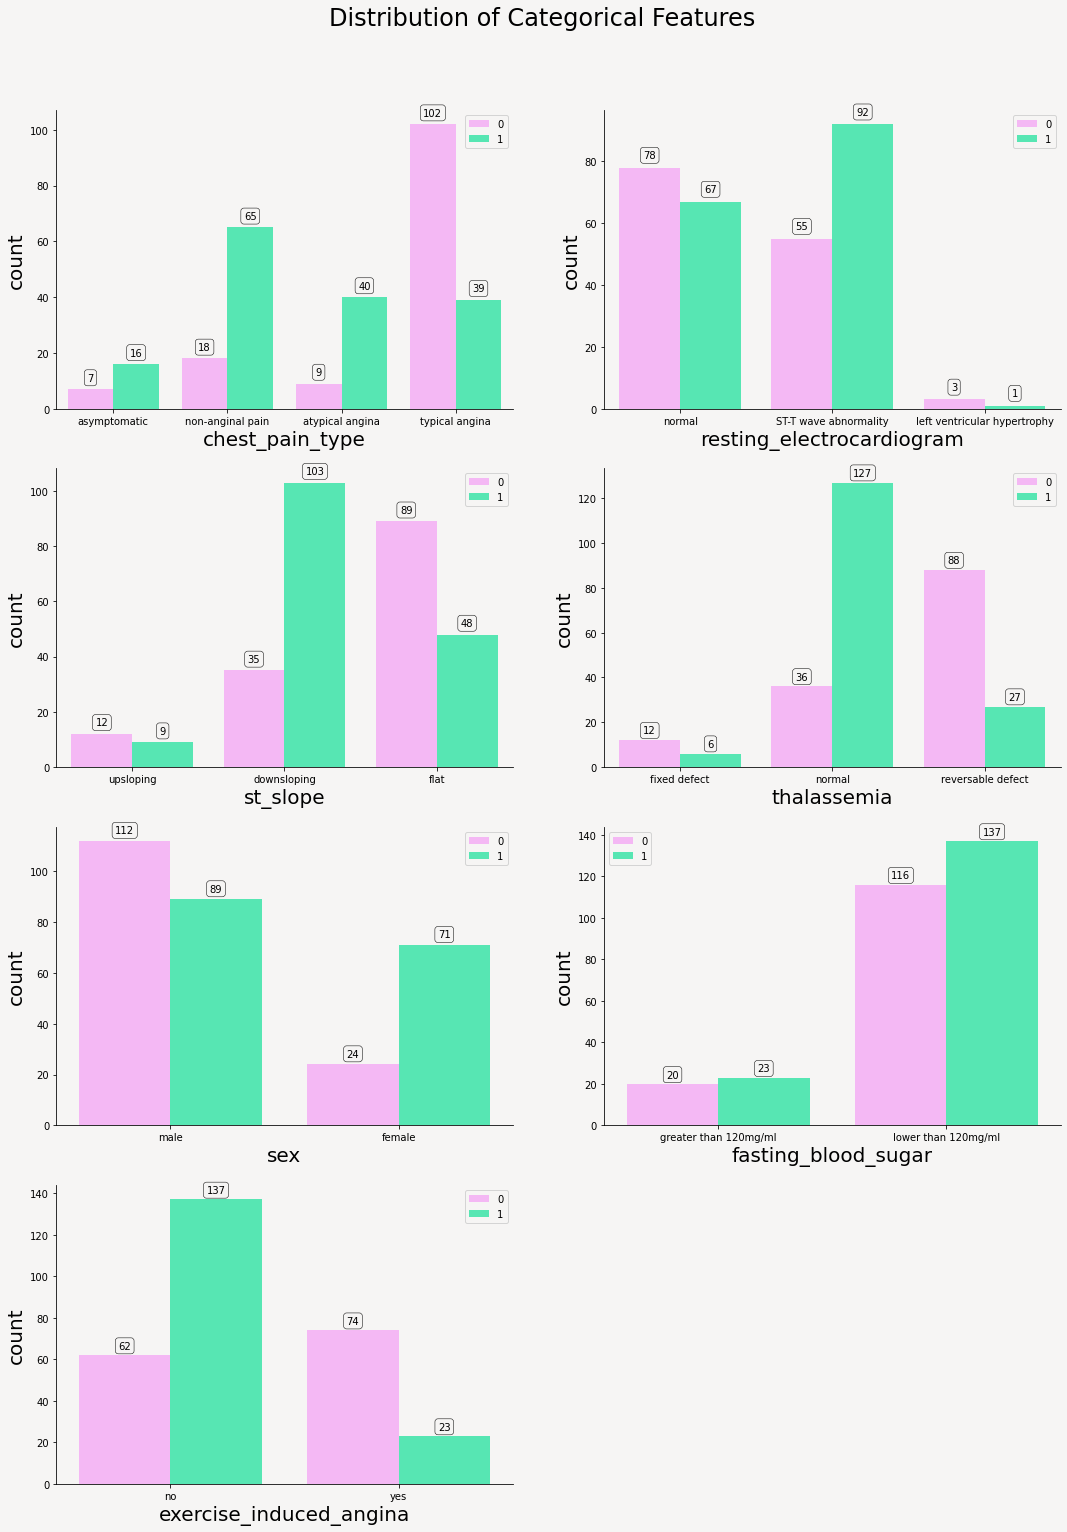

In [62]:
def count_plot(data, cat_feats):    
    L = len(cat_feats)
    ncol= 2
    nrow= int(np.ceil(L/ncol))
    remove_last= (nrow * ncol) - L

    fig, ax = plt.subplots(nrow, ncol,figsize=(18, 24), facecolor='#F6F5F4')    
    fig.subplots_adjust(top=0.92)
    ax.flat[-remove_last].set_visible(False)

    i = 1
    for col in cat_feats:
        plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')
        ax = sns.countplot(data=data, x=col, hue="target", palette=mypal[1::4])
        ax.set_xlabel(col, fontsize=20)
        ax.set_ylabel("count", fontsize=20)
        sns.despine(right=True)
        sns.despine(offset=0, trim=False) 
        plt.legend(facecolor='#F6F5F4')
        
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.0f}'.format((height)),ha="center",
                  bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))
        
        i = i +1

    plt.suptitle('Distribution of Categorical Features' ,fontsize = 24)
    return 0

count_plot(data, cat_feats[0:-1]);

##  1.4 **Correlation Heatmaps** <a class="anchor" id="1.4"></a>

Correlation heatmap is a useful tool to graphyically represent how two features are related to eachother. Depending upon the data types of the features, we need to use the appropriate correlation coefficient calculation methods. Examples are pearson's correlation coefficient, point biserial correlation, cramers'V correlation and etc. 

### 1.4.1 Pearson's correlation 

* The Pearson correlation coefficient ― is a measure of linear correlation between two sets of data. It is the ratio between the covariance of two variables and the product of their standard deviations; thus it is essentially a normalised measurement of the covariance, such that the result always has a value between −1 and 1. ([ref. ](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient))

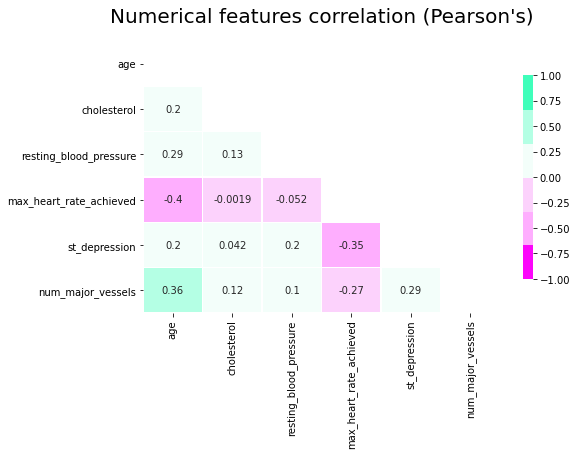

In [63]:
df_ = data[num_feats]
corr = df_.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(8, 5), facecolor=None)
cmap = sns.color_palette(mypal, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0, annot=True,
            square=False, linewidths=.5, cbar_kws={"shrink": 0.75})
ax.set_title("Numerical features correlation (Pearson's)", fontsize=20, y= 1.05);

### 1.4.2 Point biserial correlation
- A point-biserial correlation is used to measure the strength and direction of the association that exists between **one continuous variable and one dichotomous variable**. It is a special case of the Pearson’s product-moment correlation, which is applied when you have two continuous variables, whereas in this case one of the variables is measured on a dichotomous scale [[ref. ](https://statistics.laerd.com/spss-tutorials/point-biserial-correlation-using-spss-statistics.php)].

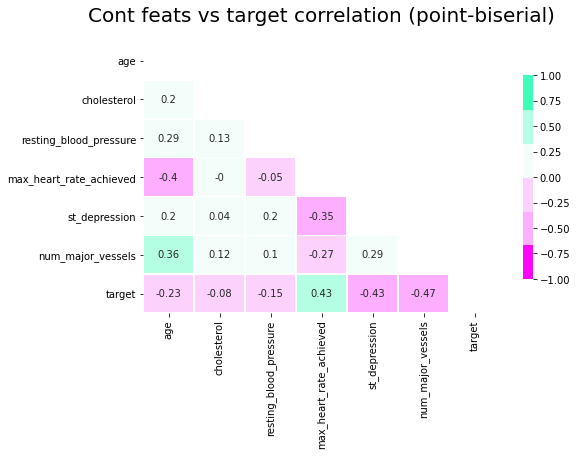

In [64]:
feats_ = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels', 'target']

def point_biserial(x, y):
    pb = stats.pointbiserialr(x, y)
    return pb[0]

rows= []
for x in feats_:
    col = []
    for y in feats_ :
        pbs =point_biserial(data[x], data[y]) 
        col.append(round(pbs,2))  
    rows.append(col)  
    
pbs_results = np.array(rows)
DF = pd.DataFrame(pbs_results, columns = data[feats_].columns, index =data[feats_].columns)

mask = np.triu(np.ones_like(DF, dtype=bool))
corr = DF.mask(mask)

f, ax = plt.subplots(figsize=(8, 5), facecolor=None)
cmap = sns.color_palette(mypal, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1, center=0, annot=True,
            square=False, linewidths=.5, cbar_kws={"shrink": 0.75})
ax.set_title("Cont feats vs target correlation (point-biserial)", fontsize=20, y= 1.05);

### 1.4.3 Cramer's V correlation

* In statistics, Cramér's V is a measure of association between **two nominal variables**, giving a value between 0 and +1 (inclusive). It is based on Pearson's chi-squared statistic and was published by Harald Cramér in 1946. [[ref. ](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V)]

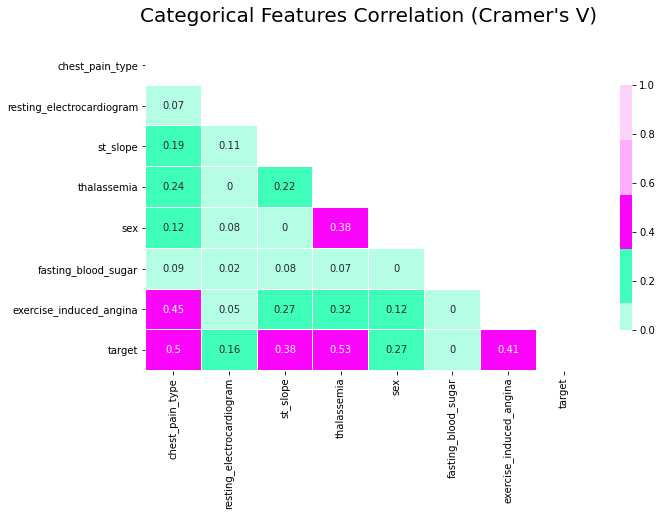

In [65]:
# the cramers_v function is copied from https://towardsdatascience.com/the-search-for-categorical-correlation-a1cf7f1888c9

def cramers_v(x, y): 
    confusion_matrix = pd.crosstab(x,y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

# calculate the correlation coefficients using the above function
data_ = data[cat_feats]
rows= []
for x in data_:
    col = []
    for y in data_ :
        cramers =cramers_v(data_[x], data_[y]) 
        col.append(round(cramers,2))
    rows.append(col)
    
cramers_results = np.array(rows)
df = pd.DataFrame(cramers_results, columns = data_.columns, index = data_.columns)

# color palette 
mypal_1= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA', '#FC05FB', '#FEAEFE', '#FCD2FC']
# plot the heat map
mask = np.triu(np.ones_like(df, dtype=bool))
corr = df.mask(mask)
f, ax = plt.subplots(figsize=(10, 6), facecolor=None)
cmap = sns.color_palette(mypal_1, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=0, center=0, annot=True,
            square=False, linewidths=.01, cbar_kws={"shrink": 0.75})
ax.set_title("Categorical Features Correlation (Cramer's V)", fontsize=20, y= 1.05);

<a href="#top">Back to top</a>

## **1.5 EDA Summary**: <a class="anchor" id="1.5"></a>

* Data size: 303 rows and 14 columns (13 independent + one target variable) > later reduced to 296 after removing faulty data points!
* Data has no missing values
* Features (columns) data type: 
    * Six features are numerical 
    * The rest (seven features) are categorical variables
* Target variable is fairly balanced, 54% no-disease to 46% has-disease
* Correlations:
    * Correlation between features is weak at best
    * From the numerical features `num_major_vessels`, `max_heart_rate_achieved` and `st_depression` are reasonabily fairly correlated with the target variable at -0.47, 0.43 and -0.43 correlation coefficient respectively.
    * From the categorical features `chest_pain_type`, `num_major_vessels`, `thalassemia`, and `exercise_induced_angina` are better correlated with the target variable, `thalassemia` being the highest at 0.52.
    * Cholestrol (to my surprize, but what do I know?) has less correlation with heart desease. 
    
**Takeaway**: features that have higher predictive power could be, **`chest_pain_type`, `num_major_vessels`, `thalassemia`, `exercise_induced_angina` `max_heart_rate_achieved`** and **`st_depression`**. We will see which features will appear as imporatnt by the classification models.
            

---
## Prepare Data for Modeling


In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['target'])
    # Sanitize column names for LightGBM/XGBoost compatibility
    X.columns = [str(c).replace(' ', '_').replace('[', '_').replace(']', '_')
                 .replace(',', '_').replace(':', '_').replace('{', '_')
                 .replace('}', '_').replace('<', '_').replace('>', '_')
                 .replace('"', '_') for c in X.columns]
y = df['target']

# Handle non-numeric columns for modeling
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


---
## Step 1: Baseline Model Comparison (LazyPredict)

Quick automated comparison of multiple models to establish baselines.


In [ ]:
from lazypredict.Supervised import LazyClassifier

lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = lazy_clf.fit(X_train, X_test, y_train, y_test)

print(models)


---
## Step 2: Final Pipeline (PyCaret)

Automated ML pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `compare_models()` → model selection
- `finalize_model()` → train on full data


In [ ]:
from pycaret.classification import *

clf_setup = setup(data=df, target='target', session_id=42, verbose=False)

# Compare models and select best
best_model = compare_models()

# Display comparison results
print(best_model)


In [ ]:
# Evaluate the best model
evaluate_model(best_model)


In [ ]:
# Finalize the model (train on full dataset)
final_model = finalize_model(best_model)

print('Final model:', final_model)